1-Bibliotecas:

In [1]:
import scipy.io as io
import numpy as np
import h5py
import os
import matplotlib.pyplot as plt
import amc_mlp_pipeline as mlp_pipe
import importlib
importlib.reload(mlp_pipe)

<module 'amc_mlp_pipeline' from 'C:\\WINDOWS\\system32\\amc_mlp_pipeline.py'>

2-Carrega Base

In [2]:
path = r'C:\Users\Admin\Downloads\archive(1)'

with h5py.File(os.path.join(path, 'X_train.mat'), 'r') as f:
    X_train = np.array(f['X_train'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_val.mat'), 'r') as f:
    X_val = np.array(f['X_val'], dtype='float32').T

with h5py.File(os.path.join(path, 'X_test.mat'), 'r') as f:
    X_test = np.array(f['X_test'], dtype='float32').T

Y_train = io.loadmat(os.path.join(path, 'Y_train.mat'))['Y_train']
Y_val   = io.loadmat(os.path.join(path, 'Y_val.mat'))['Y_val']
Y_test  = io.loadmat(os.path.join(path, 'Y_test.mat'))['Y_test']

lbl_train = io.loadmat(os.path.join(path, 'lbl_train.mat'))['lbl_train']
lbl_val   = io.loadmat(os.path.join(path, 'lbl_val.mat'))['lbl_val']
lbl_test  = io.loadmat(os.path.join(path, 'lbl_test.mat'))['lbl_test']

In [3]:
print("Y_train shape:", Y_train.shape)
print("Y_train[:5]:", Y_train[:5])

print("lbl_train shape:", lbl_train.shape)
print("lbl_train[:5]:", lbl_train[:5])

Y_train shape: (469200, 23)
Y_train[:5]: [[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]
lbl_train shape: (469200, 6)
lbl_train[:5]: [[ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  4.22743774e-03
   1.28290481e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  2.00246104e-01
   7.98754715e-02  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  1.26933729e-01
   2.25750427e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.48238329e-02
   1.46626138e-01  0.00000000e+00]
 [ 1.00000000e+00 -1.20000000e+01  1.02400000e+03  6.20988175e-02
   1.12184316e-01  0.00000000e+00]]


3-Define quais sinais modelar

In [4]:
idx_classes_paper = [0, 4, 5, 8, 10, 11, 12, 13, 14, 21, 22]

class_names_full = ['LFM', '2FSK', '4FSK', '8FSK', 'FM_Costas', '2PSK', '4PSK', '8PSK',
                    'PM_Barker', 'PM_Huffman', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3',
                    'PM_P4', 'PM_Px', 'PM_ZadoffChu', 'PM_T1', 'PM_T2', 'PM_T3', 'PM_T4', 'NM', 'Noise']

classes_paper = [class_names_full[i] for i in idx_classes_paper]
print(classes_paper)

['LFM', 'FM_Costas', '2PSK', 'PM_Barker', 'PM_Frank', 'PM_P1', 'PM_P2', 'PM_P3', 'PM_P4', 'NM', 'Noise']


4-Filtra Base com Sinais Selecionados

In [5]:
y_idx_train = np.argmax(Y_train, axis=1)
y_idx_val   = np.argmax(Y_val, axis=1)
y_idx_test  = np.argmax(Y_test, axis=1)

# 1) Cria máscara para as 11 classes do paper
mask_train = np.isin(y_idx_train, idx_classes_paper)
mask_val   = np.isin(y_idx_val, idx_classes_paper)
mask_test  = np.isin(y_idx_test, idx_classes_paper)

# 2) Filtra
X_train_f, Y_train_f, lbl_train_f = X_train[mask_train], Y_train[mask_train], lbl_train[mask_train]
X_val_f,   Y_val_f,   lbl_val_f   = X_val[mask_val],     Y_val[mask_val],     lbl_val[mask_val]
X_test_f,  Y_test_f,  lbl_test_f  = X_test[mask_test],   Y_test[mask_test],   lbl_test[mask_test]

print("Treino:", X_train.shape, "->", X_train_f.shape)
print("Validação:", X_val.shape, "->", X_val_f.shape)
print("Teste:", X_test.shape, "->", X_test_f.shape)

# 3) Libera memória do que não precisa mais
import gc
del X_train, X_val, X_test, Y_train, Y_val, Y_test
gc.collect()

Treino: (469200, 1024, 2) -> (224400, 1024, 2)
Validação: (156400, 1024, 2) -> (74800, 1024, 2)
Teste: (156400, 1024, 2) -> (74800, 1024, 2)


0

In [6]:
# Re-mapear os rótulos para 0–10
remap = {old: new for new, old in enumerate(idx_classes_paper)}

y_idx_train_f = np.array([remap[c] for c in y_idx_train[mask_train]])
y_idx_val_f   = np.array([remap[c] for c in y_idx_val[mask_val]])
y_idx_test_f  = np.array([remap[c] for c in y_idx_test[mask_test]])

# One-hot para 11 classes
from tensorflow.keras.utils import to_categorical
Y_train_f = to_categorical(y_idx_train_f, num_classes=11)
Y_val_f   = to_categorical(y_idx_val_f, num_classes=11)
Y_test_f  = to_categorical(y_idx_test_f, num_classes=11)


--- Estatísticas básicas por classe ---
Classe             Média I      Std I    Média Q      Std Q
LFM                -0.0001     0.3881     0.0002     0.3880
FM_Costas          -0.0000     0.3720     0.0010     0.3713
2PSK                0.0000     0.3882    -0.0002     0.3879
PM_Barker          -0.0070     0.3905    -0.0004     0.3878
PM_Frank            0.0024     0.3695     0.0003     0.3685
PM_P1               0.0022     0.3695     0.0001     0.3687
PM_P2              -0.0012     0.3698    -0.0007     0.3691
PM_P3               0.0023     0.3694    -0.0001     0.3683
PM_P4               0.0022     0.3693    -0.0002     0.3686
NM                  0.0002     0.3882    -0.0001     0.3881
Noise               0.0001     0.2613     0.0000     0.2613

--- Gerando gráficos de EDA ---


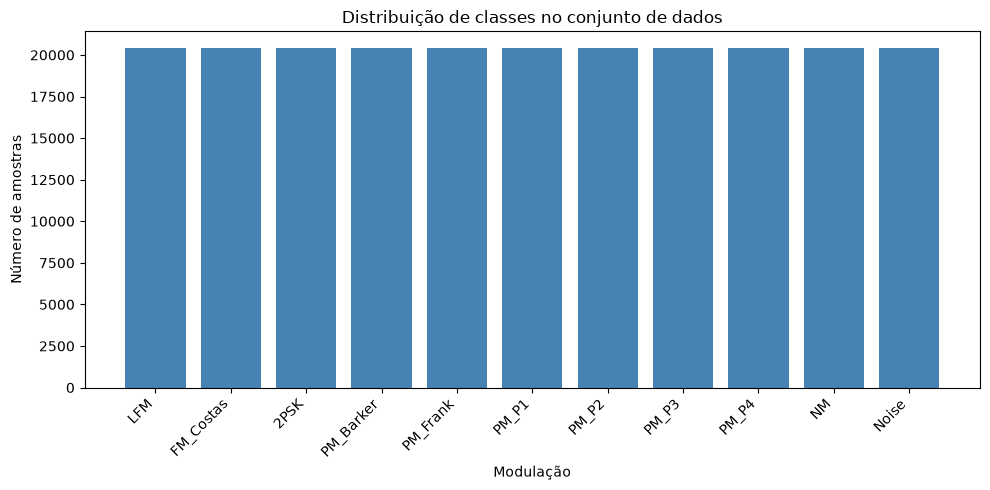

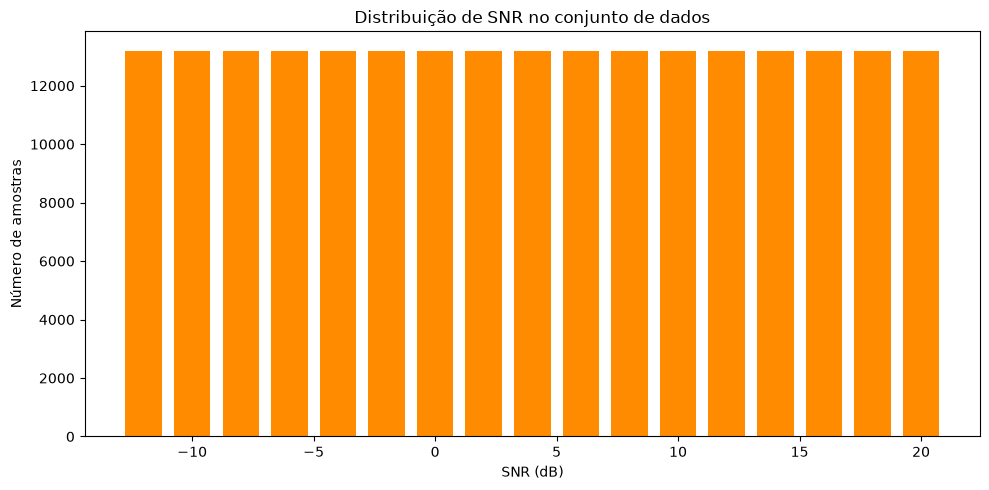

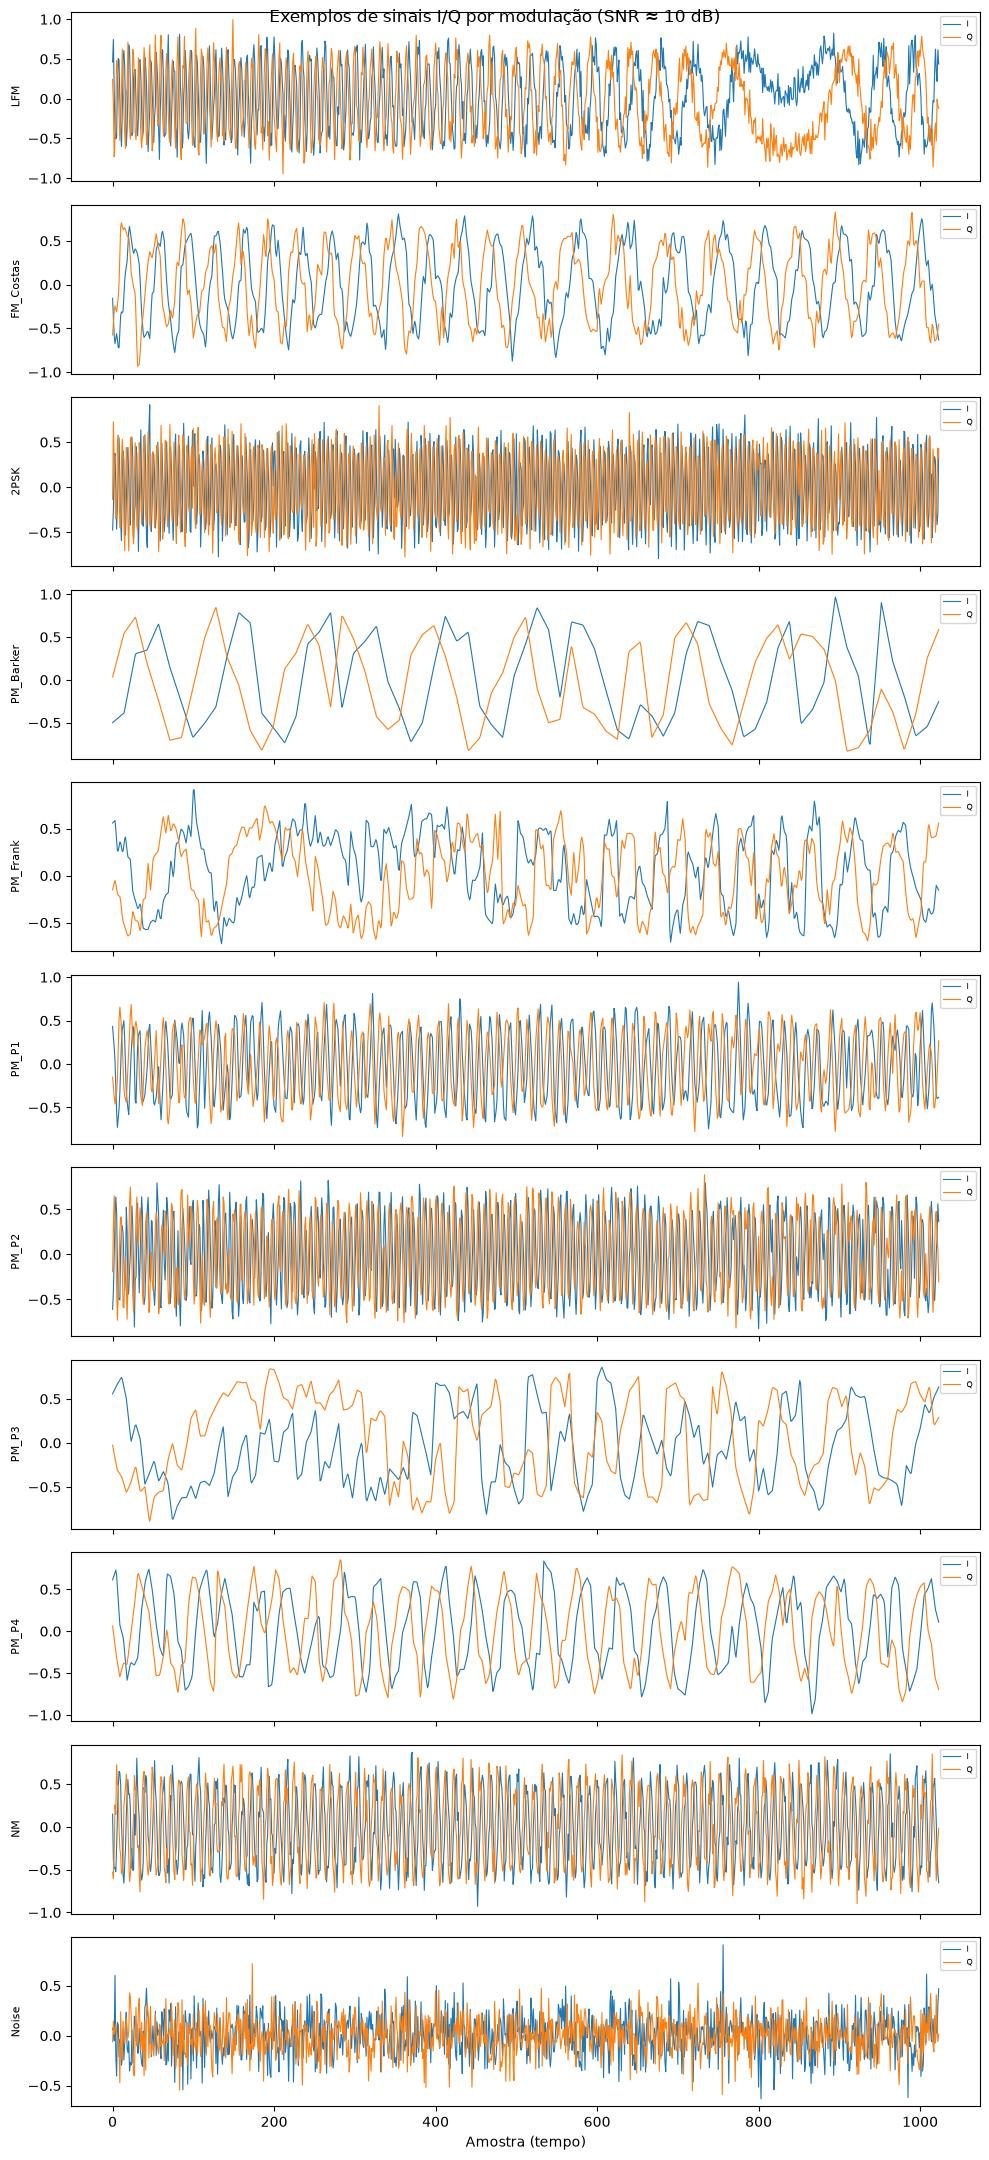

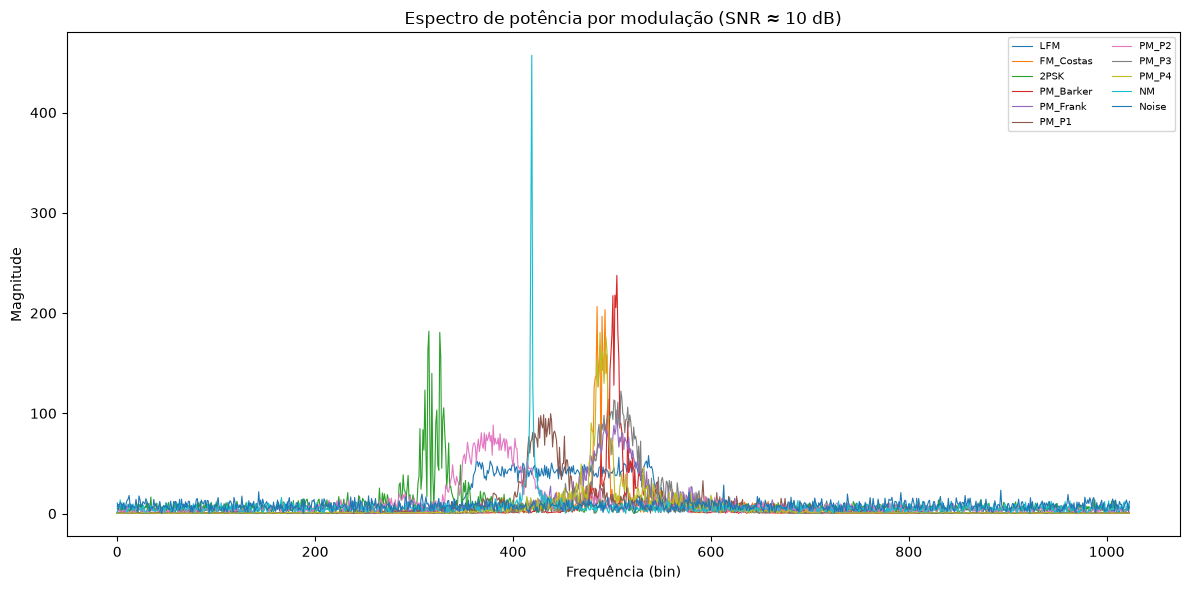

In [7]:
snr_train_f = lbl_train_f[:, 1].astype(int)

mlp_pipe.run_eda(X_train_f, y_idx_train_f, snr_train_f)

In [8]:
# 1) Extrai features do sinal BRUTO (não do achatado!)
X_train_feat = mlp_pipe.extract_features(X_train_f)
X_val_feat   = mlp_pipe.extract_features(X_val_f)
X_test_feat  = mlp_pipe.extract_features(X_test_f)

# 2) Normaliza com estatísticas do treino
mean, std = mlp_pipe.compute_normalization_stats(X_train_feat)
X_train_norm = mlp_pipe.normalize(X_train_feat, mean, std)
X_val_norm   = mlp_pipe.normalize(X_val_feat, mean, std)
X_test_norm  = mlp_pipe.normalize(X_test_feat, mean, std)

# 3) Treina (class_weight já entra por padrão)
model, history = mlp_pipe.train_mlp(
    X_train_norm, y_idx_train_f,
    X_val_norm, y_idx_val_f,
    input_dim=X_train_norm.shape[1]
)

Class weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0}
Epoch 1/100
877/877 - 44s - 50ms/step - accuracy: 0.0915 - loss: 3.3777 - val_accuracy: 0.1054 - val_loss: 2.6040
Epoch 2/100
877/877 - 42s - 48ms/step - accuracy: 0.4659 - loss: 1.4344 - val_accuracy: 0.6149 - val_loss: 0.8838
Epoch 3/100
877/877 - 41s - 47ms/step - accuracy: 0.6046 - loss: 0.9155 - val_accuracy: 0.6748 - val_loss: 0.7319
Epoch 4/100
877/877 - 41s - 47ms/step - accuracy: 0.6631 - loss: 0.7575 - val_accuracy: 0.7075 - val_loss: 0.6592
Epoch 5/100
877/877 - 42s - 47ms/step - accuracy: 0.6998 - loss: 0.6705 - val_accuracy: 0.7154 - val_loss: 0.6212
Epoch 6/100
877/877 - 41s - 47ms/step - accuracy: 0.7222 - loss: 0.6201 - val_accuracy: 0.7289 - val_loss: 0.5980
Epoch 7/100
877/877 - 41s - 46ms/step - accuracy: 0.7340 - loss: 0.5897 - val_accuracy: 0.7308 - val_loss: 0.5980
Epoch 8/100
877/877 - 41s - 46ms/step - accuracy: 0.7416 - loss: 0.5719 - val_accuracy: 0.7392 - 


Acurácia geral no teste: 80.73%

              precision    recall  f1-score   support

         LFM     0.9207    0.8815    0.9007      6800
   FM_Costas     0.9523    0.9568    0.9545      6800
        2PSK     0.9156    0.8588    0.8863      6800
   PM_Barker     0.9754    0.9693    0.9723      6800
    PM_Frank     0.6842    0.7147    0.6991      6800
       PM_P1     0.6135    0.5765    0.5944      6800
       PM_P2     0.6081    0.6546    0.6305      6800
       PM_P3     0.7255    0.7009    0.7130      6800
       PM_P4     0.6052    0.5907    0.5979      6800
          NM     0.9907    0.9982    0.9944      6800
       Noise     0.8929    0.9784    0.9337      6800

    accuracy                         0.8073     74800
   macro avg     0.8076    0.8073    0.8070     74800
weighted avg     0.8076    0.8073    0.8070     74800



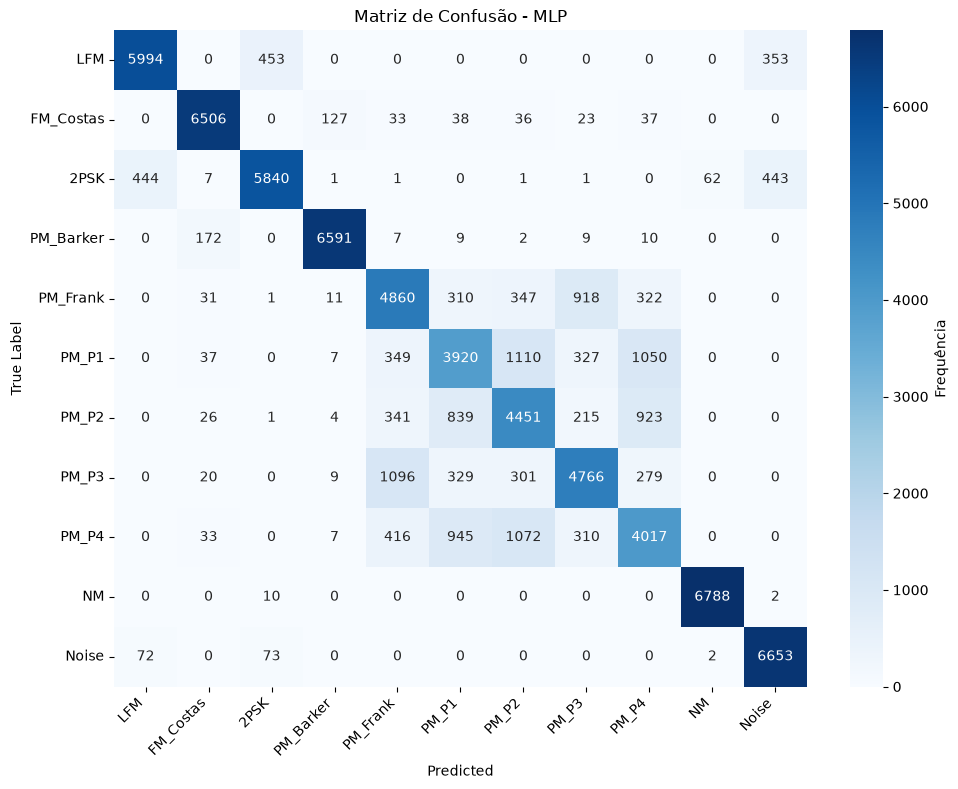

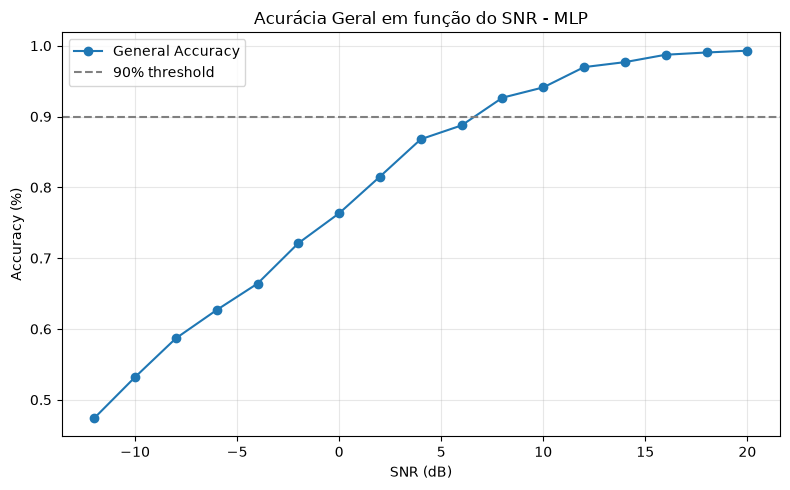

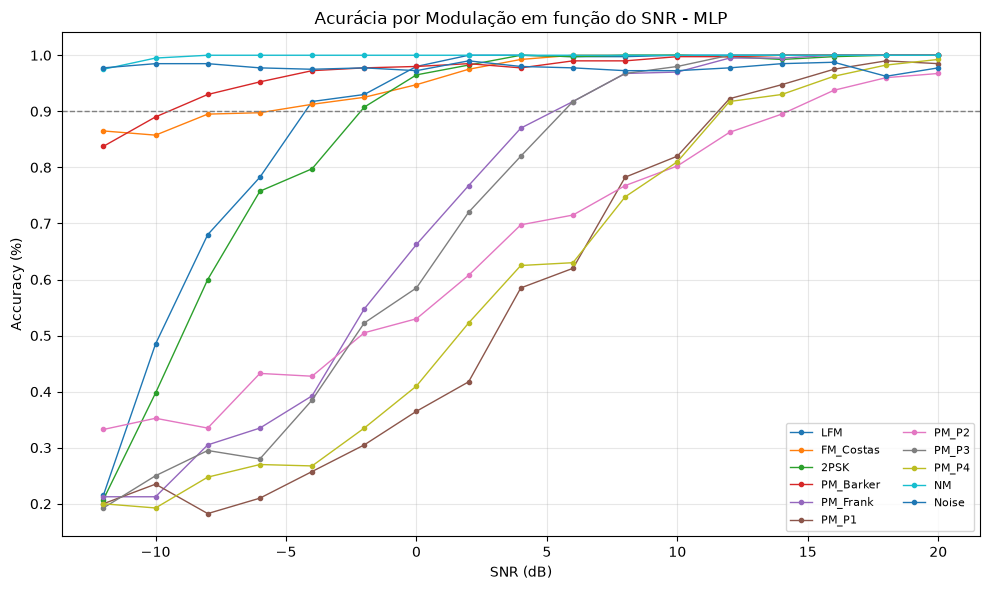


SNR mínimo (geral) para 90% de acurácia: 8 dB
SNR mínimo por modulação: {'LFM': -4, 'FM_Costas': -4, '2PSK': -2, 'PM_Barker': -8, 'PM_Frank': 6, 'PM_P1': 12, 'PM_P2': 16, 'PM_P3': 6, 'PM_P4': 12, 'NM': -12, 'Noise': -12}
Modulação limitante: PM_P2 (16 dB)


In [9]:
X_test_feat = mlp_pipe.extract_features(X_test_f)
X_test_norm = mlp_pipe.normalize(X_test_feat, mean, std)
snr_test_f = lbl_test_f[:, 1].astype(int)

results = mlp_pipe.run_evaluation(model, X_test_norm, y_idx_test_f, snr_test_f)